# Currency Exchange Insights — Exploratory Data Analysis

Source: `data/currency.db` (SQLite), built by `data_pipeline/fetch_data.py` → `clean_transform.py` → `load_to_db.py`.

Covers 1 year of trailing daily exchange rates, base currency USD, sourced from the Frankfurter v2 API (ECB + partner central banks).

This notebook covers, per the capstone brief:
1. Time series line plots per currency pair
2. Distribution of daily returns (outliers/extreme moves)
3. Correlation heatmap across currency pairs
4. Rolling volatility comparison
5. Seasonality check (day-of-week / month-end patterns)
6. Top gainers/losers over the year


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DB_PATH = "../data/currency.db"

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM exchange_rates", conn, parse_dates=["date"])
conn.close()

print(df.shape)
df.head()

(60922, 13)


,id,date,base_currency,target_currency,rate,is_trading_day,daily_pct_change,ma_7,ma_30,volatility_30d,day_of_week,month,is_month_end
0,1,2025-07-11,USD,AED,NaN,0,NaN,NaN,NaN,NaN,Friday,7,0
1,2,2025-07-12,USD,AED,3.6725,1,NaN,NaN,NaN,NaN,Saturday,7,0
2,3,2025-07-13,USD,AED,3.6725,1,0.0,NaN,NaN,NaN,Sunday,7,0
3,4,2025-07-14,USD,AED,3.6725,1,0.0,NaN,NaN,NaN,Monday,7,0
4,5,2025-07-15,USD,AED,3.6725,1,0.0,NaN,NaN,NaN,Tuesday,7,0


## 0. Data overview

In [2]:
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Base currency:", df["base_currency"].unique())
print("Target currencies:", sorted(df["target_currency"].unique()))
print("Trading-day rows:", int(df["is_trading_day"].sum()), "/", len(df))
df.isnull().sum()

Date range: 2025-07-11 to 2026-07-12
Base currency: <StringArray>
['USD']
Length: 1, dtype: str
Target currencies: ['AED', 'AFN', 'ALL', 'AMD', 'ANG', 'AOA', 'ARS', 'AUD', 'AWG', 'AZN', 'BAM', 'BBD', 'BDT', 'BGN', 'BHD', 'BIF', 'BMD', 'BND', 'BOB', 'BRL', 'BSD', 'BTN', 'BWP', 'BYN', 'BZD', 'CAD', 'CDF', 'CHF', 'CLP', 'CNH', 'CNY', 'COP', 'CRC', 'CUP', 'CVE', 'CZK', 'DJF', 'DKK', 'DOP', 'DZD', 'EGP', 'ERN', 'ETB', 'EUR', 'FJD', 'FKP', 'GBP', 'GEL', 'GGP', 'GHS', 'GIP', 'GMD', 'GNF', 'GTQ', 'GYD', 'HKD', 'HNL', 'HTG', 'HUF', 'IDR', 'ILS', 'IMP', 'INR', 'IQD', 'IRR', 'ISK', 'JEP', 'JMD', 'JOD', 'JPY', 'KES', 'KGS', 'KHR', 'KMF', 'KPW', 'KRW', 'KWD', 'KYD', 'KZT', 'LAK', 'LBP', 'LKR', 'LRD', 'LSL', 'LYD', 'MAD', 'MDL', 'MGA', 'MKD', 'MMK', 'MNT', 'MOP', 'MRO', 'MRU', 'MUR', 'MVR', 'MWK', 'MXN', 'MYR', 'MZN', 'NAD', 'NGN', 'NIO', 'NOK', 'NPR', 'NZD', 'OMR', 'PAB', 'PEN', 'PGK', 'PHP', 'PKR', 'PLN', 'PYG', 'QAR', 'RON', 'RSD', 'RUB', 'RWF', 'SAR', 'SBD', 'SCR', 'SDG', 'SEK', 'SGD', 'SHP', 'S

id                      0
date                    0
base_currency           0
target_currency         0
rate                 9307
is_trading_day          0
daily_pct_change    13924
ma_7                31580
ma_30               33512
volatility_30d      33596
day_of_week             0
month                   0
is_month_end            0
dtype: int64

Rows where `is_trading_day == 0` are weekend/holiday placeholders added by `clean_transform.py`'s
calendar reindex — `rate` and the rolling/derived columns are `NaN` there. Drop them for any analysis
that should only look at actual published rates.

In [3]:
trading = df[df["is_trading_day"] == 1].copy()
trading = trading.sort_values(["target_currency", "date"])
trading.shape

(51615, 13)

## 1. Time series line plots per currency pair

### A note on scope

This dataset covers **166 target currencies** — far more than a single chart can show legibly. A per-currency subplot grid, a full correlation heatmap, or a legend listing every currency all become unreadable at this scale (166 subplots, a 166×166 heatmap, 166 overlapping legend entries).

So: charts that plot *individual currency series* (time series, correlation, return distributions, rolling volatility over time) are scoped to a curated set of major/liquid currencies below. Every **aggregate** stat — top gainers/losers, volatility ranking, day-of-week and month-end effects — still uses the full 166-currency dataset; only the chart, not the analysis, is scoped.

In [4]:
# Curated set of major/liquid currencies for per-currency visuals.
# Aggregate analyses below (gainers/losers, volatility ranking, seasonality)
# still run over ALL currencies in `trading` / `df`, not just this list.
MAJOR_CURRENCIES = [c for c in
    ["EUR", "GBP", "JPY", "CHF", "AUD", "CAD", "CNY", "INR", "MXN", "BRL", "ZAR", "SGD"]
    if c in trading["target_currency"].unique()]
print(f"{len(trading['target_currency'].unique())} currencies in the full dataset; "
      f"{len(MAJOR_CURRENCIES)} major currencies used for per-currency charts:")
print(MAJOR_CURRENCIES)

166 currencies in the full dataset; 12 major currencies used for per-currency charts:
['EUR', 'GBP', 'JPY', 'CHF', 'AUD', 'CAD', 'CNY', 'INR', 'MXN', 'BRL', 'ZAR', 'SGD']


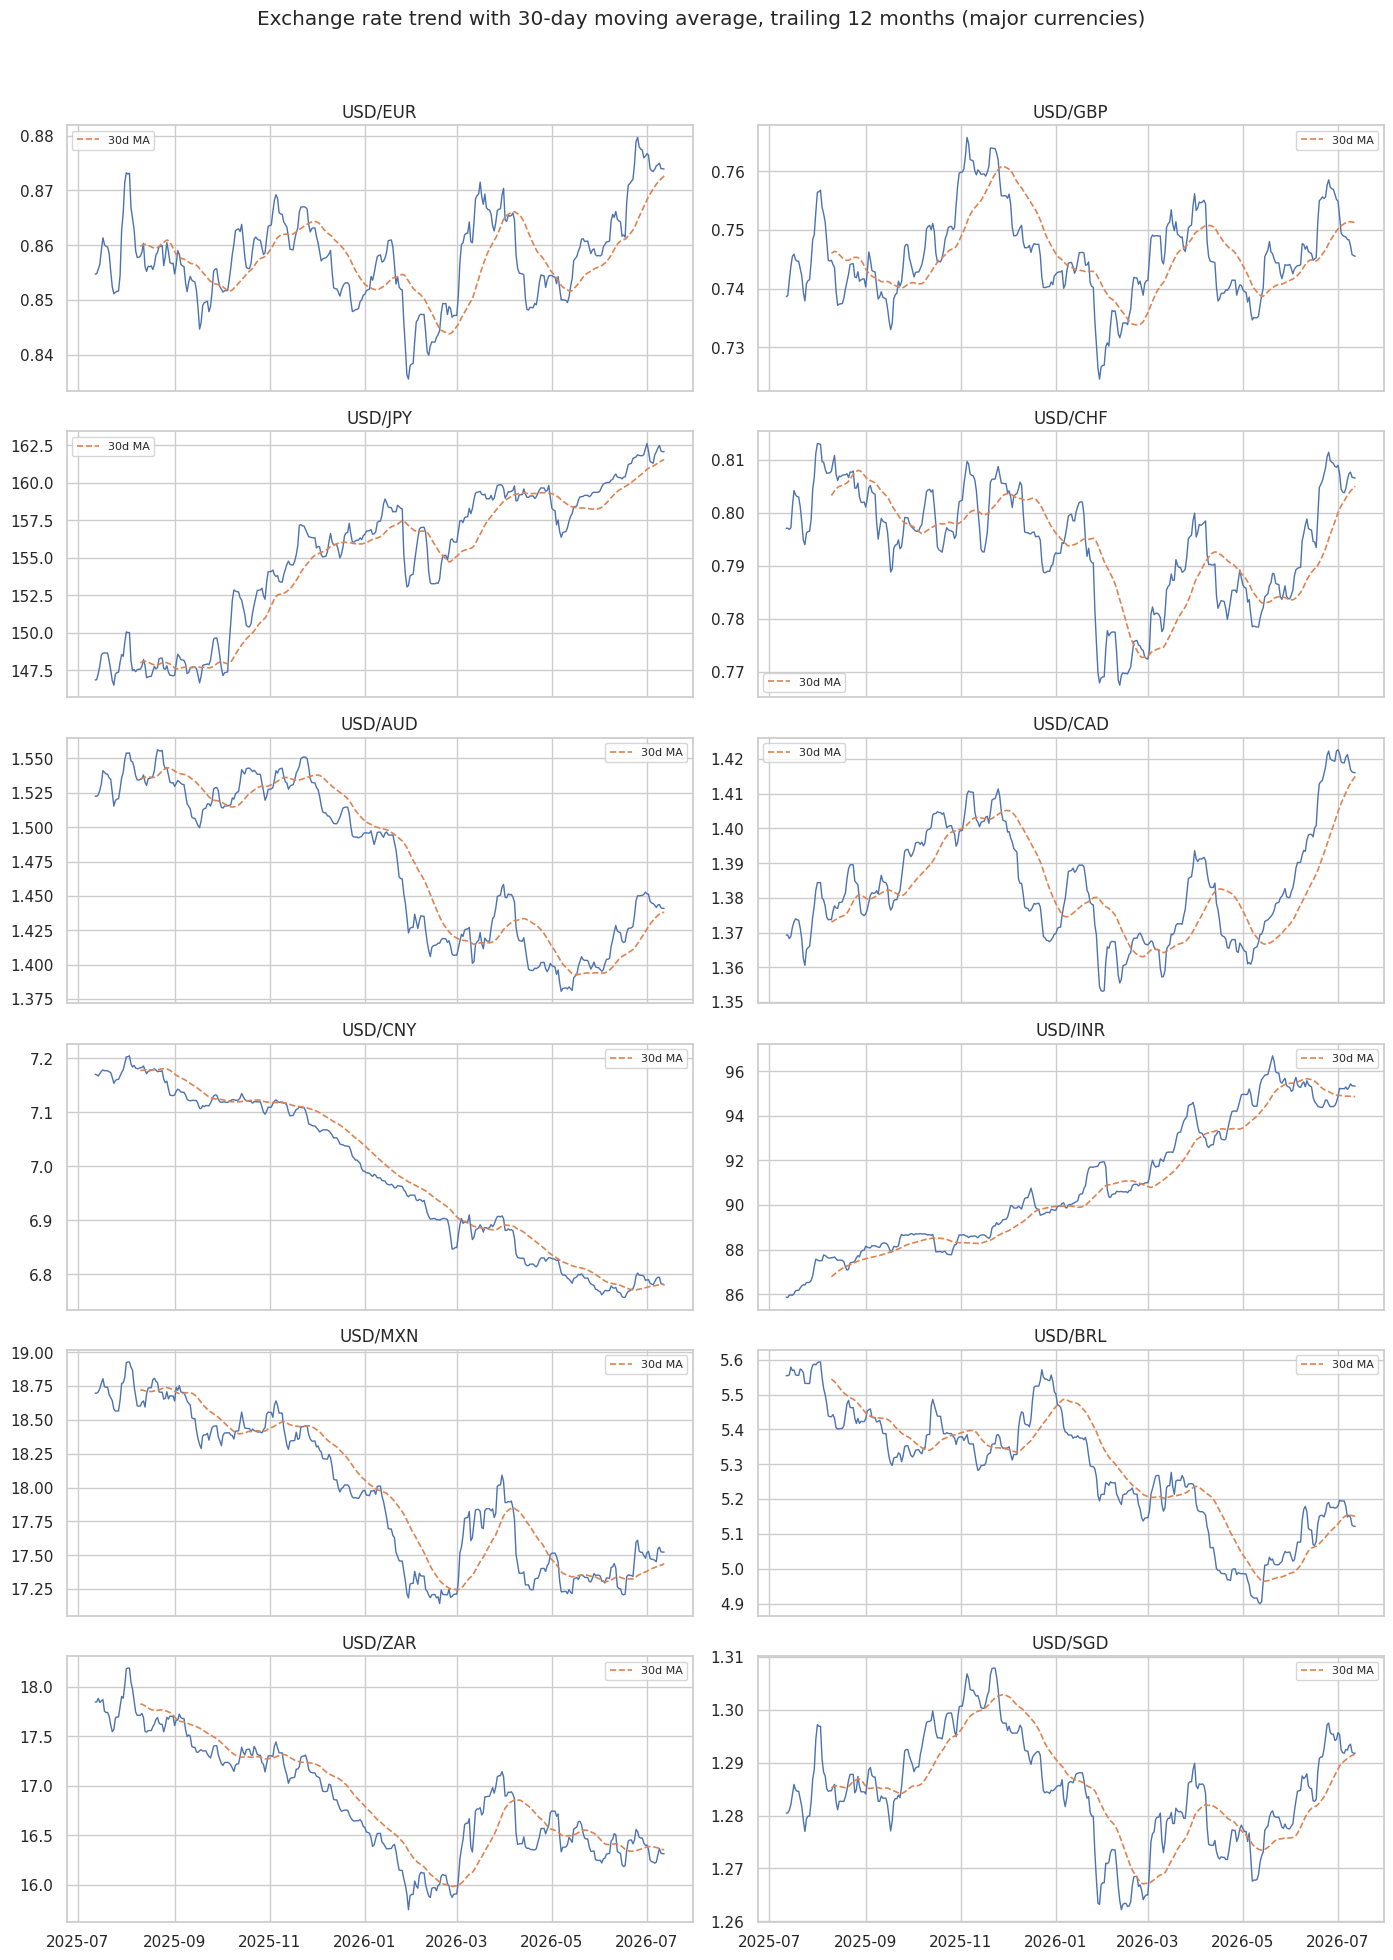

In [5]:
currencies = MAJOR_CURRENCIES
n = len(currencies)
ncols = 2
nrows = -(-n // ncols)  # ceil

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows), sharex=True)
axes = axes.flatten()

for ax, cur in zip(axes, currencies):
    sub = trading[trading["target_currency"] == cur]
    ax.plot(sub["date"], sub["rate"], linewidth=1)
    ax.plot(sub["date"], sub["ma_30"], linewidth=1.2, linestyle="--", label="30d MA")
    ax.set_title(f"USD/{cur}")
    ax.legend(fontsize=8)

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("Exchange rate trend with 30-day moving average, trailing 12 months (major currencies)", y=1.02)
fig.tight_layout()
plt.show()

## 2. Distribution of daily returns

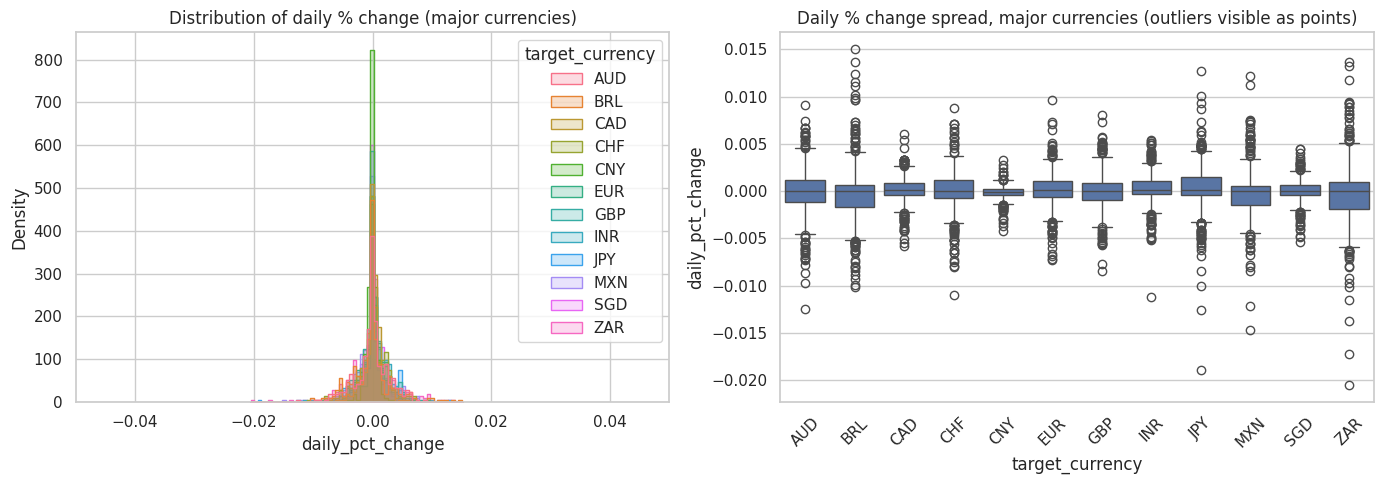

In [6]:
major_trading = trading[trading["target_currency"].isin(MAJOR_CURRENCIES)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=major_trading, x="daily_pct_change", hue="target_currency",
             bins=60, element="step", stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("Distribution of daily % change (major currencies)")
axes[0].set_xlim(-0.05, 0.05)

sns.boxplot(data=major_trading, x="target_currency", y="daily_pct_change", ax=axes[1])
axes[1].set_title("Daily % change spread, major currencies (outliers visible as points)")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

In [7]:
# Flag the most extreme single-day moves across all currencies
extreme_moves = (
    trading.dropna(subset=["daily_pct_change"])
    .reindex(trading["daily_pct_change"].abs().sort_values(ascending=False).index)
    .head(10)[["date", "target_currency", "rate", "daily_pct_change"]]
)
extreme_moves

,date,target_currency,rate,daily_pct_change
23670,2026-01-09,IRR,530757.00000,11.629554
48624,2026-01-07,SYP,114.04000,-0.989698
23675,2026-01-14,IRR,996764.00000,0.453859
6968,2026-07-08,BOB,8.39930,0.224352
56357,2026-02-02,XAG,0.01056,0.211009
23673,2026-01-12,IRR,667438.00000,0.208026
8581,2025-11-28,BYN,2.91510,-0.145733
59294,2026-02-03,XPT,0.00045,0.125000
56361,2026-02-06,XAG,0.01279,0.118007
56358,2026-02-03,XAG,0.01163,0.101326


## 3. Correlation heatmap across currency pairs

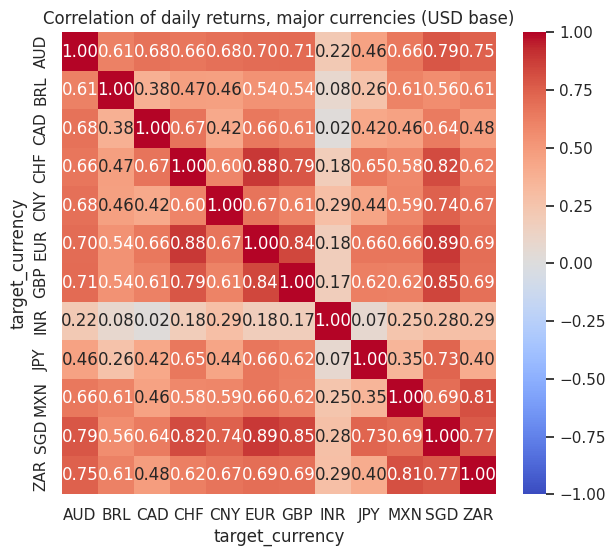

In [8]:
pivot = trading[trading["target_currency"].isin(MAJOR_CURRENCIES)] \
    .pivot_table(index="date", columns="target_currency", values="rate")
corr = pivot.pct_change().corr()   # correlate daily returns, not raw levels

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation of daily returns, major currencies (USD base)")
plt.show()

Correlating daily **returns** (`pct_change`) rather than raw rate levels avoids the spurious
correlation you'd get from two unrelated series that both happen to trend over a year.

## 4. Rolling volatility comparison

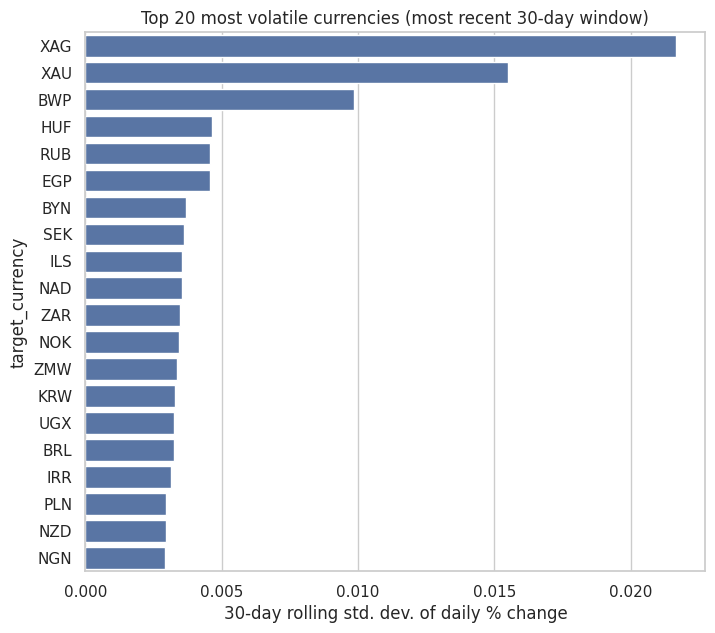

Full ranking: 83 currencies. Top 5 / bottom 5 shown below.


,target_currency,volatility_30d
0,XAG,0.021650
1,XAU,0.015494
2,BWP,0.009852
3,HUF,0.004634
4,RUB,0.004585
78,AED,0.000000
79,ANG,0.000000
80,TMT,0.000000
81,USD,0.000000
82,SAR,0.000000


In [9]:
latest_vol = (
    trading.dropna(subset=["volatility_30d"])
    .sort_values("date")
    .groupby("target_currency")
    .tail(1)[["target_currency", "volatility_30d"]]
    .sort_values("volatility_30d", ascending=False)
    .reset_index(drop=True)
)

# Ranking covers all currencies; the chart shows only the top 20 most volatile
# (166 bars on one axis is illegible — see latest_vol for the full ranking).
top20 = latest_vol.head(20)

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(data=top20, y="target_currency", x="volatility_30d", ax=ax, orient="h")
ax.set_title("Top 20 most volatile currencies (most recent 30-day window)")
ax.set_xlabel("30-day rolling std. dev. of daily % change")
plt.show()

print(f"Full ranking: {len(latest_vol)} currencies. Top 5 / bottom 5 shown below.")
pd.concat([latest_vol.head(5), latest_vol.tail(5)])

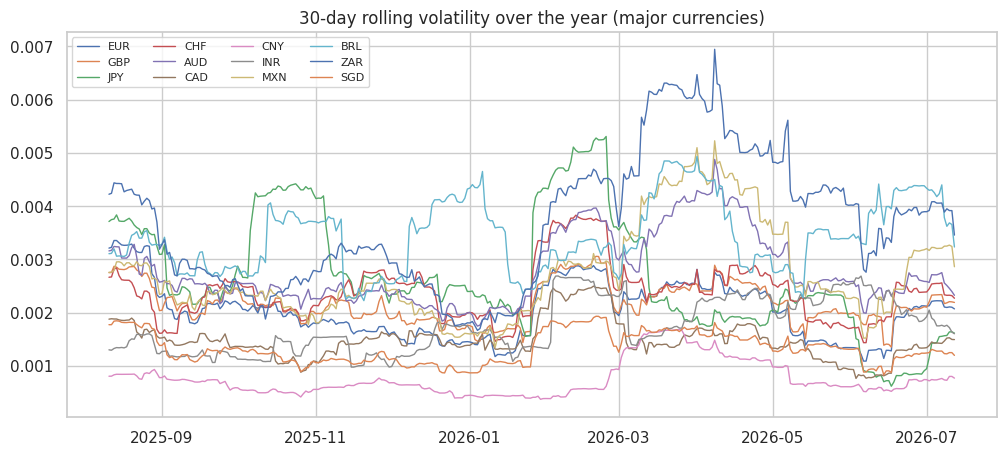

In [10]:
# Volatility over time, majors only (166 overlapping lines/legend entries is unreadable)
fig, ax = plt.subplots(figsize=(12, 5))
for cur in MAJOR_CURRENCIES:
    sub = trading[trading["target_currency"] == cur]
    ax.plot(sub["date"], sub["volatility_30d"], label=cur, linewidth=1)
ax.set_title("30-day rolling volatility over the year (major currencies)")
ax.legend(ncol=4, fontsize=8)
plt.show()

## 5. Seasonality check — day-of-week and month-end patterns

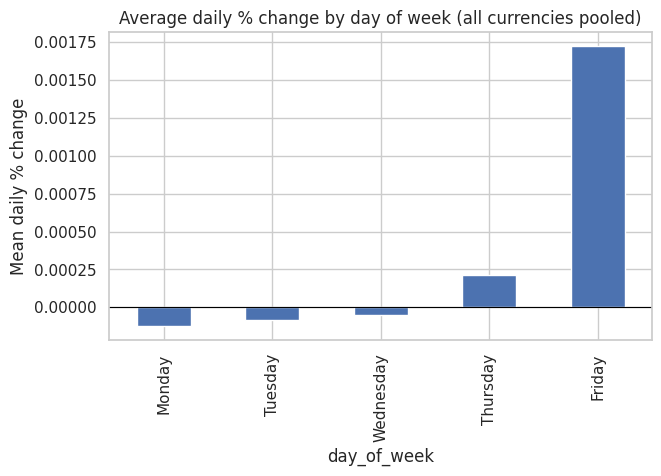

In [11]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
dow_effect = (
    trading[trading["day_of_week"].isin(dow_order)]
    .groupby("day_of_week")["daily_pct_change"]
    .mean()
    .reindex(dow_order)
)

fig, ax = plt.subplots(figsize=(7, 4))
dow_effect.plot(kind="bar", ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Average daily % change by day of week (all currencies pooled)")
ax.set_ylabel("Mean daily % change")
plt.show()

In [12]:
month_end_effect = trading.groupby("is_month_end")["daily_pct_change"].agg(["mean", "std", "count"])
month_end_effect.index = month_end_effect.index.map({0: "Regular day", 1: "Month-end"})
month_end_effect

,mean,std,count
is_month_end,,,
Regular day,0.000297,0.055061,45429
Month-end,0.000614,0.004420,1569


With ~1 year of data and 5 trading days a week, treat any day-of-week or month-end effect here as
a starting hypothesis rather than a statistically robust finding — a proper significance test would need
several years of history to rule out noise.

## 6. Top gainers/losers over the year

In [13]:
start_end = (
    trading.sort_values("date")
    .groupby("target_currency")
    .agg(start_rate=("rate", "first"), end_rate=("rate", "last"))
)
start_end["pct_change_ytd"] = (start_end["end_rate"] / start_end["start_rate"] - 1) * 100
start_end = start_end.sort_values("pct_change_ytd", ascending=False)

print(f"Full ranking: {len(start_end)} currencies. Top 10 / bottom 10 shown below.")
pd.concat([start_end.head(10), start_end.tail(10)])

Full ranking: 166 currencies. Top 10 / bottom 10 shown below.


,start_rate,end_rate,pct_change_ytd
target_currency,,,
IRR,42040.00000,1.371810e+06,3163.106565
VES,113.95000,6.984800e+02,512.970601
BOB,6.90540,8.486600e+00,22.898022
LYD,5.40210,6.418700e+00,18.818608
ARS,1258.72000,1.490700e+03,18.429833
TRY,40.12900,4.693300e+01,16.955319
ETB,136.79000,1.595700e+02,16.653264
LKR,300.30000,3.351200e+02,11.595072
IDR,16219.00000,1.806000e+04,11.350885


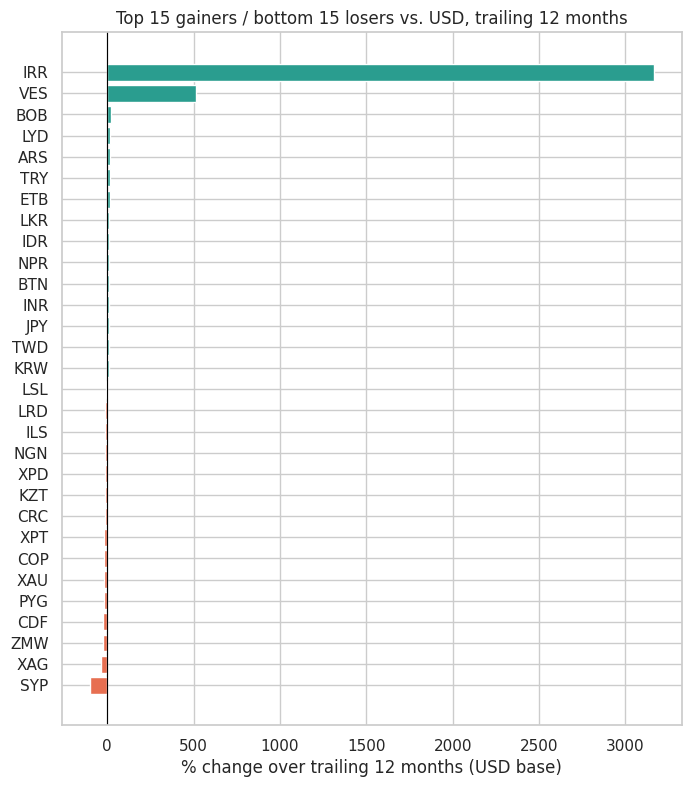

In [14]:
# 166 bars on one chart is unreadable — show the 15 biggest gainers and 15 biggest
# losers only. `start_end` above still holds the full ranking.
movers = pd.concat([start_end.head(15), start_end.tail(15)]).sort_values("pct_change_ytd")

fig, ax = plt.subplots(figsize=(8, 9))
colors = ["#2a9d8f" if v >= 0 else "#e76f51" for v in movers["pct_change_ytd"]]
ax.barh(movers.index, movers["pct_change_ytd"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("% change over trailing 12 months (USD base)")
ax.set_title("Top 15 gainers / bottom 15 losers vs. USD, trailing 12 months")
plt.show()

## Key findings (fill in after running on the real 1-year pull)

- Best performer vs. USD: **`{best}`** (+{best_pct:.1f}%)
- Worst performer vs. USD: **`{worst}`** ({worst_pct:.1f}%)
- Most volatile currency (latest 30-day window): **`{most_vol}`**
- Least volatile currency: **`{least_vol}`**
- Any notable day-of-week or month-end effect: _describe here once the real data confirms or rules it out_
- Most/least correlated pair: _read off the heatmap above_

*(This cell's numbers are computed live in the next cell — copy them up into this markdown summary for the README's "Key Insights" section.)*

In [15]:
best = start_end["pct_change_ytd"].idxmax()
worst = start_end["pct_change_ytd"].idxmin()
most_vol = latest_vol.iloc[0]["target_currency"]
least_vol = latest_vol.iloc[-1]["target_currency"]

print(f"Best performer: {best} ({start_end.loc[best, 'pct_change_ytd']:.2f}%)")
print(f"Worst performer: {worst} ({start_end.loc[worst, 'pct_change_ytd']:.2f}%)")
print(f"Most volatile (latest 30d): {most_vol}")
print(f"Least volatile (latest 30d): {least_vol}")

Best performer: IRR (3163.11%)
Worst performer: SYP (-99.04%)
Most volatile (latest 30d): XAG
Least volatile (latest 30d): SAR
